In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [2]:
df = pd.read_csv("../dataset/hdfc_loan_dataset_full_enriched.csv")

In [3]:
df.head()

,Loan_ID,Bank,Customer_Name,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,...,Loan_to_Annual_Income,Customer_Sentiment,Religion,State,City,PIN_Code,Aadhaar_Synthetic,Phone_Number,Email,Occupation
0,HDFC100001,HDFC Bank,Rohan Verma,Male,No,2,Graduate,Salaried,56976,0,...,11.747,Positive,Hindu,Delhi,Dwarka,857743,6.940000e+11,9068671773,rohan.verma@example.in,Farmer
1,HDFC100002,HDFC Bank,Rohan Verma,Male,No,0,Graduate,Unemployed,1856,0,...,40.381,Negative,Hindu,Punjab,Ludhiana,863836,6.330000e+11,9990772625,rohan.verma@example.in,Civil Engineer
2,HDFC100003,HDFC Bank,Aditya Nair,Female,Yes,0,Graduate,Salaried,64553,0,...,3.082,Positive,Hindu,Maharashtra,Nagpur,834796,1.660000e+11,9195085016,aditya.nair@example.in,Medical Representative
3,HDFC100004,HDFC Bank,Ananya Joshi,Male,No,0,Graduate,Salaried,88450,0,...,0.621,Negative,Hindu,Gujarat,Vadodara,438590,5.528183e+10,9179335548,ananya.joshi@example.in,Marketing Executive
4,HDFC100005,HDFC Bank,Harpreet Singh,Male,Yes,3,Graduate,Self-Employed,9539,0,...,1.736,Neutral,Sikh,West Bengal,Kolkata,495224,1.560000e+11,9795137116,harpreet.singh@example.in,Shopkeeper


In [4]:
df.shape

(1000, 47)

In [ ]:
df.columns

Index(['Loan_ID', 'Bank', 'Customer_Name', 'Gender', 'Married', 'Dependents',
       'Education', 'Employment_Status', 'Applicant_Income',
       'Coapplicant_Income', 'Loan_Amount', 'Loan_Term_Months',
       'Credit_History', 'Property_Area', 'Age', 'Loan_Status', 'CIBIL_Score',
       'Annual_Household_Income', 'Debt_to_Income_Ratio', 'Purpose_of_Loan',
       'Existing_EMIs', 'Number_of_Previous_Loans', 'Default_History_Count',
       'Employment_Length_Years', 'Business_Type', 'Asset_Value', 'Guarantor',
       'Co-signer_Relationship', 'Monthly_Expense', 'Organization_Type',
       'Region_Branch', 'Mobile_Verified', 'Email_Verified',
       'Institutional_Relationships', 'Application_Text', 'Customer_Feedback',
       'Agent_Notes', 'Loan_to_Annual_Income', 'Customer_Sentiment',
       'Religion', 'State', 'City', 'PIN_Code', 'Aadhaar_Synthetic',
       'Phone_Number', 'Email', 'Occupation'],
      dtype='str')

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 47 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Loan_ID                      1000 non-null   str    
 1   Bank                         1000 non-null   str    
 2   Customer_Name                1000 non-null   str    
 3   Gender                       1000 non-null   str    
 4   Married                      1000 non-null   str    
 5   Dependents                   1000 non-null   int64  
 6   Education                    1000 non-null   str    
 7   Employment_Status            1000 non-null   str    
 8   Applicant_Income             1000 non-null   int64  
 9   Coapplicant_Income           1000 non-null   int64  
 10  Loan_Amount                  1000 non-null   int64  
 11  Loan_Term_Months             1000 non-null   int64  
 12  Credit_History               1000 non-null   int64  
 13  Property_Area                1

In [5]:
df.describe()

,Dependents,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term_Months,Credit_History,Age,CIBIL_Score,Annual_Household_Income,Debt_to_Income_Ratio,Existing_EMIs,Number_of_Previous_Loans,Default_History_Count,Employment_Length_Years,Asset_Value,Monthly_Expense,Loan_to_Annual_Income,PIN_Code,Aadhaar_Synthetic,Phone_Number
count,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.00000,1.000000e+03,1.000000e+03
mean,0.849000,42430.057000,9727.11400,2.216713e+06,159.132000,0.72300,34.412000,653.01300,6.258861e+05,148.118157,18173.390000,0.865000,0.147000,2.434000,1.908042e+06,23603.427000,10.163103,509976.40800,4.853217e+11,9.500193e+09
std,0.964951,28133.210769,20568.25945,2.635021e+06,127.056704,0.44774,8.572616,73.83654,4.724545e+05,1974.599103,16298.460525,0.911925,0.499641,2.791673,1.481451e+06,18054.598235,25.415631,289145.26265,2.925311e+11,2.875105e+08
min,0.000000,0.000000,0.00000,1.884000e+03,12.000000,0.00000,18.000000,384.00000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.003000,622.00000,2.589553e+08,9.002443e+09
25%,0.000000,18260.000000,0.00000,3.729465e+05,36.000000,0.00000,28.000000,605.75000,2.639520e+05,0.031000,1741.750000,0.000000,0.000000,0.000000,7.424400e+05,9159.250000,0.645750,263067.50000,2.190000e+11,9.254018e+09
50%,1.000000,40675.500000,0.00000,9.720460e+05,120.000000,1.00000,35.000000,654.00000,5.512440e+05,0.332000,16289.500000,1.000000,0.000000,2.000000,1.634312e+06,20787.500000,2.309000,517643.50000,4.735000e+11,9.498140e+09
75%,2.000000,61037.250000,7956.50000,3.315038e+06,300.000000,1.00000,40.000000,704.00000,8.565480e+05,0.795000,29718.500000,1.000000,0.000000,3.000000,2.726302e+06,33067.750000,8.326750,756922.00000,7.300000e+11,9.750462e+09
max,3.000000,149266.000000,123461.00000,1.379096e+07,360.000000,1.00000,66.000000,878.00000,2.555340e+06,38342.000000,82436.000000,5.000000,3.000000,15.000000,7.742001e+06,97762.000000,269.754000,998910.00000,9.990000e+11,9.999102e+09


In [6]:
df.isnull().sum()

Loan_ID                          0
Bank                             0
Customer_Name                    0
Gender                           0
Married                          0
Dependents                       0
Education                        0
Employment_Status                0
Applicant_Income                 0
Coapplicant_Income               0
Loan_Amount                      0
Loan_Term_Months                 0
Credit_History                   0
Property_Area                    0
Age                              0
Loan_Status                      0
CIBIL_Score                      0
Annual_Household_Income          0
Debt_to_Income_Ratio             0
Purpose_of_Loan                  0
Existing_EMIs                    0
Number_of_Previous_Loans         0
Default_History_Count            0
Employment_Length_Years          0
Business_Type                  799
Asset_Value                      0
Guarantor                        0
Co-signer_Relationship         234
Monthly_Expense     

In [7]:
df.duplicated().sum()

np.int64(0)

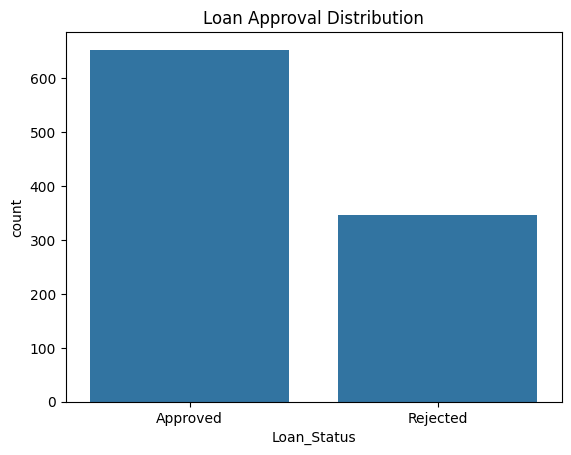

In [8]:
#Loan Approval Distribution
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Approval Distribution")
plt.show()

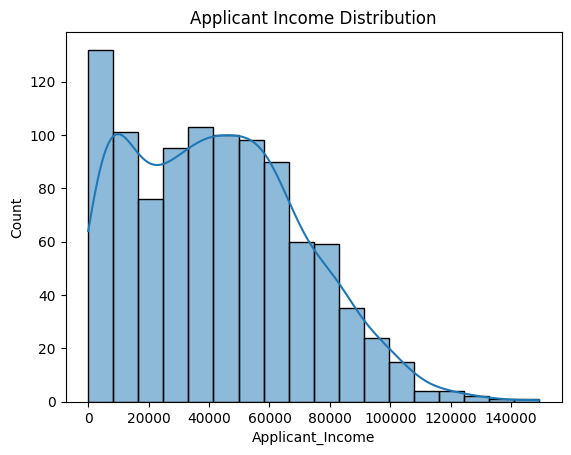

In [9]:
#Income Distribution
sns.histplot(df['Applicant_Income'], kde=True)
plt.title("Applicant Income Distribution")
plt.show()

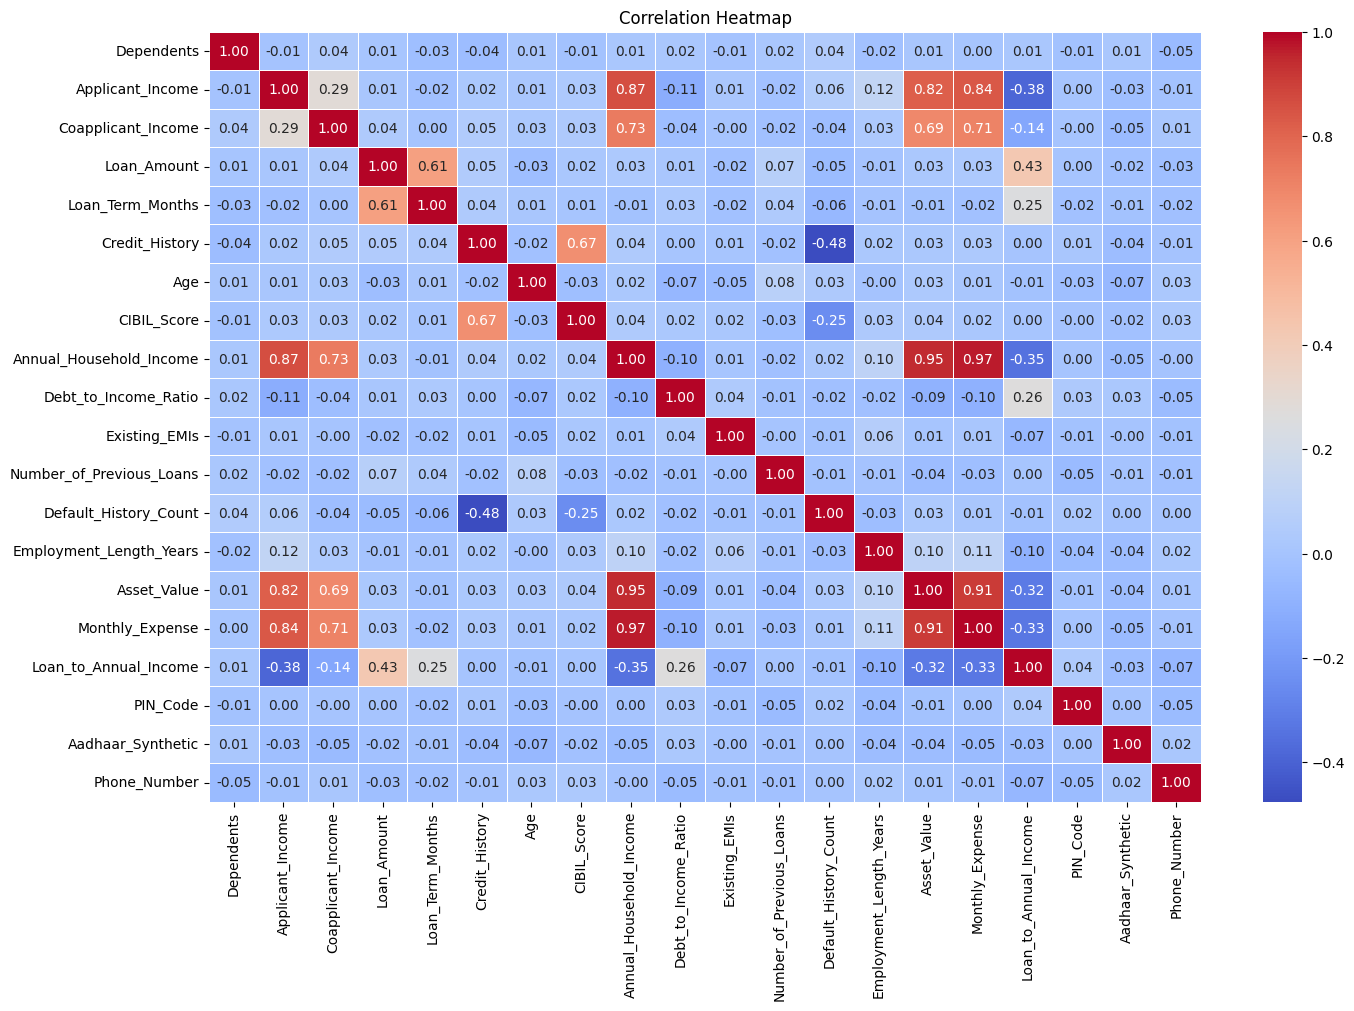

In [10]:
#Correlation HeatMap
plt.figure(figsize=(16,10)) 
sns.heatmap(df.corr(numeric_only=True), fmt=".2f", linewidths=0.5,annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

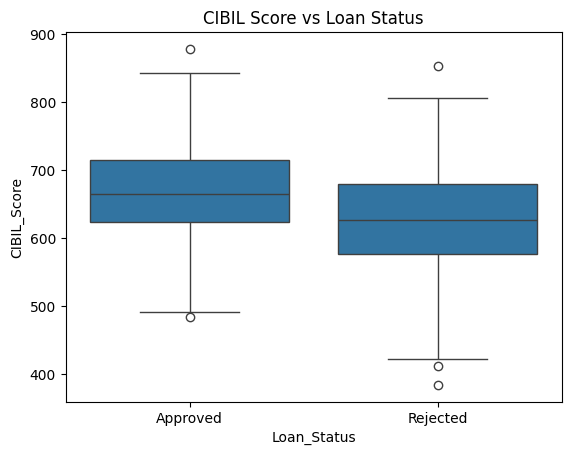

In [11]:
#CIBIL Score Analysis
sns.boxplot(x='Loan_Status', y='CIBIL_Score', data=df)
plt.title("CIBIL Score vs Loan Status")
plt.show()

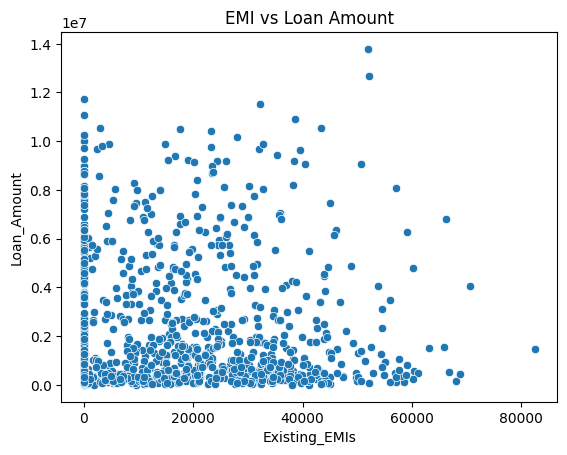

In [12]:
#EMI vs Loan Amount
sns.scatterplot(x='Existing_EMIs', y='Loan_Amount', data=df)
plt.title("EMI vs Loan Amount")
plt.show()

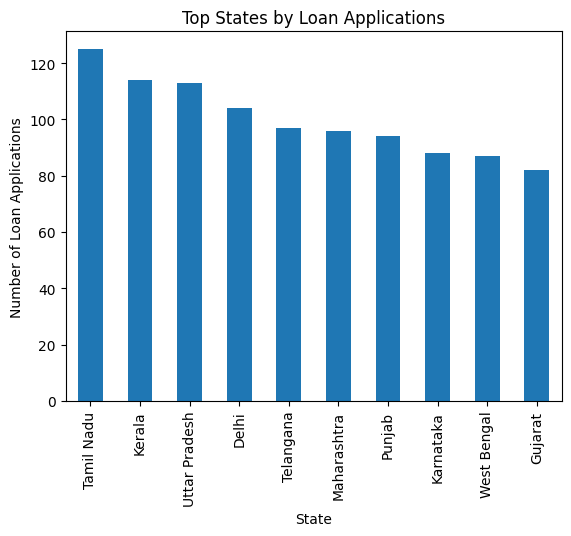

In [13]:
#State wise loan trends
df['State'].value_counts().head(10).plot(kind='bar')
plt.title("Top States by Loan Applications")
plt.xlabel("State")
plt.ylabel("Number of Loan Applications")
plt.show()

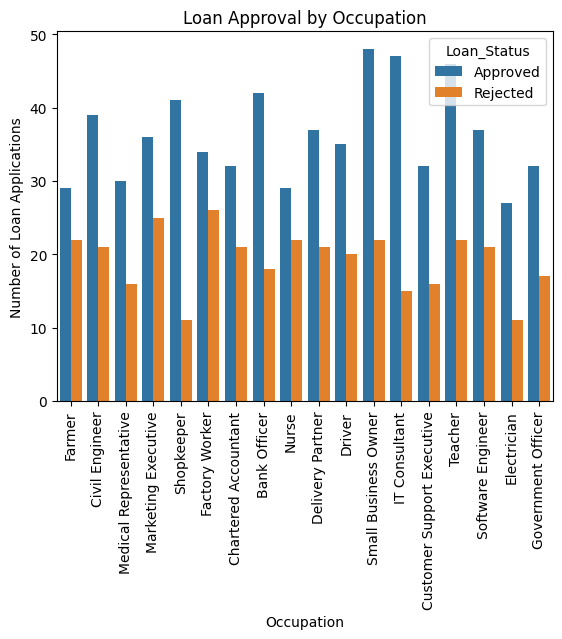

In [14]:
#Loan approval by occupation
sns.countplot(x='Occupation', hue='Loan_Status', data=df)
plt.xticks(rotation=90)
plt.title("Loan Approval by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Number of Loan Applications")
plt.show()

In [15]:
#Missing Value Handling
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [16]:
#Handling missing values for categorical columns
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

C:\Users\User\AppData\Local\Temp\ipykernel_1196\1461802178.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In [17]:
#Encoding Categorical features
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [18]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(df[num_cols])

In [19]:
#Outlier Handling
Q1 = df['Applicant_Income'].quantile(0.25)
Q3 = df['Applicant_Income'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['Applicant_Income'] >= lower) &
        (df['Applicant_Income'] <= upper)]

In [21]:
df.to_csv("../dataset/hdfc_loan_dataset_full_enriched_cleaned.csv", index=False)